In [10]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import brentq
from scipy.special import erf

from pathlib import Path
IMAGES_DIR = Path("images")
IMAGES_DIR.mkdir(exist_ok=True)

In [2]:
config = {
    "g": np.nan,
    "I0": np.nan,
    "alpha": 1.0,
    "theta": 0.0,
    "sigma": 0.5,
}

In [3]:
def transfer(v, theta, sigma):
    """
    Gaussian-closed Heaviside transfer:

        F(v) = 1/2 * [1 + erf((v-theta)/(sqrt(2)*sigma))]
    """
    return 0.5 * (
        1.0 + erf((v - theta) / (np.sqrt(2.0) * sigma))
    )


def transfer_derivative(v, theta, sigma):
    return (
        np.exp(-0.5 * ((v - theta) / sigma) ** 2)
        / (np.sqrt(2.0 * np.pi) * sigma)
    )

In [4]:
def fun_V_star(Vs, g, I0, config):
    alpha = config["alpha"]
    theta = config["theta"]
    sigma = config["sigma"]

    return (g * transfer(Vs, theta, sigma) + I0) / alpha


def residual_V_star(Vs, g, I0, config):
    # Solve Vs = fun_V_star(Vs, g, I0, config)
    return fun_V_star(Vs, g, I0, config) - Vs


def solve_V_star(g, I0, config, V_bounds=(-100.0, 100.0)):
    v_min, v_max = V_bounds

    try:
        return brentq(
            residual_V_star,
            v_min,
            v_max,
            args=(g, I0, config),
        )
    except ValueError:
        # No sign change, so Brent's method cannot identify a root.
        return np.nan

In [30]:
def compute_V_star_surface(g_values, I0_values, config, V_bounds=(-100, 100)):
    g_grid, I0_grid = np.meshgrid(g_values, I0_values)
    V_star_grid = np.full(g_grid.shape, np.nan, dtype=float)

    for i in range(g_grid.shape[0]):
        for j in range(g_grid.shape[1]):
            V_star_grid[i, j] = solve_V_star(
                g=g_grid[i, j],
                I0=I0_grid[i, j],
                config=config,
                V_bounds=V_bounds,
            )

    return g_grid, I0_grid, V_star_grid

def compute_beta_surface(g_grid, V_star_grid, config):
    theta = config['theta']
    sigma = config['sigma']
    return g_grid * transfer_derivative(V_star_grid, theta, sigma)

In [31]:
N = 200
bound = 20
g_values = np.linspace(-bound, bound, N)
I0_values = np.linspace(-bound, bound, N)

g_grid, I0_grid, V_star_grid = compute_V_star_surface(
    g_values,
    I0_values,
    config,
    V_bounds=(-50, 50),
)

beta_grid = compute_beta_surface(g_grid, V_star_grid, config)

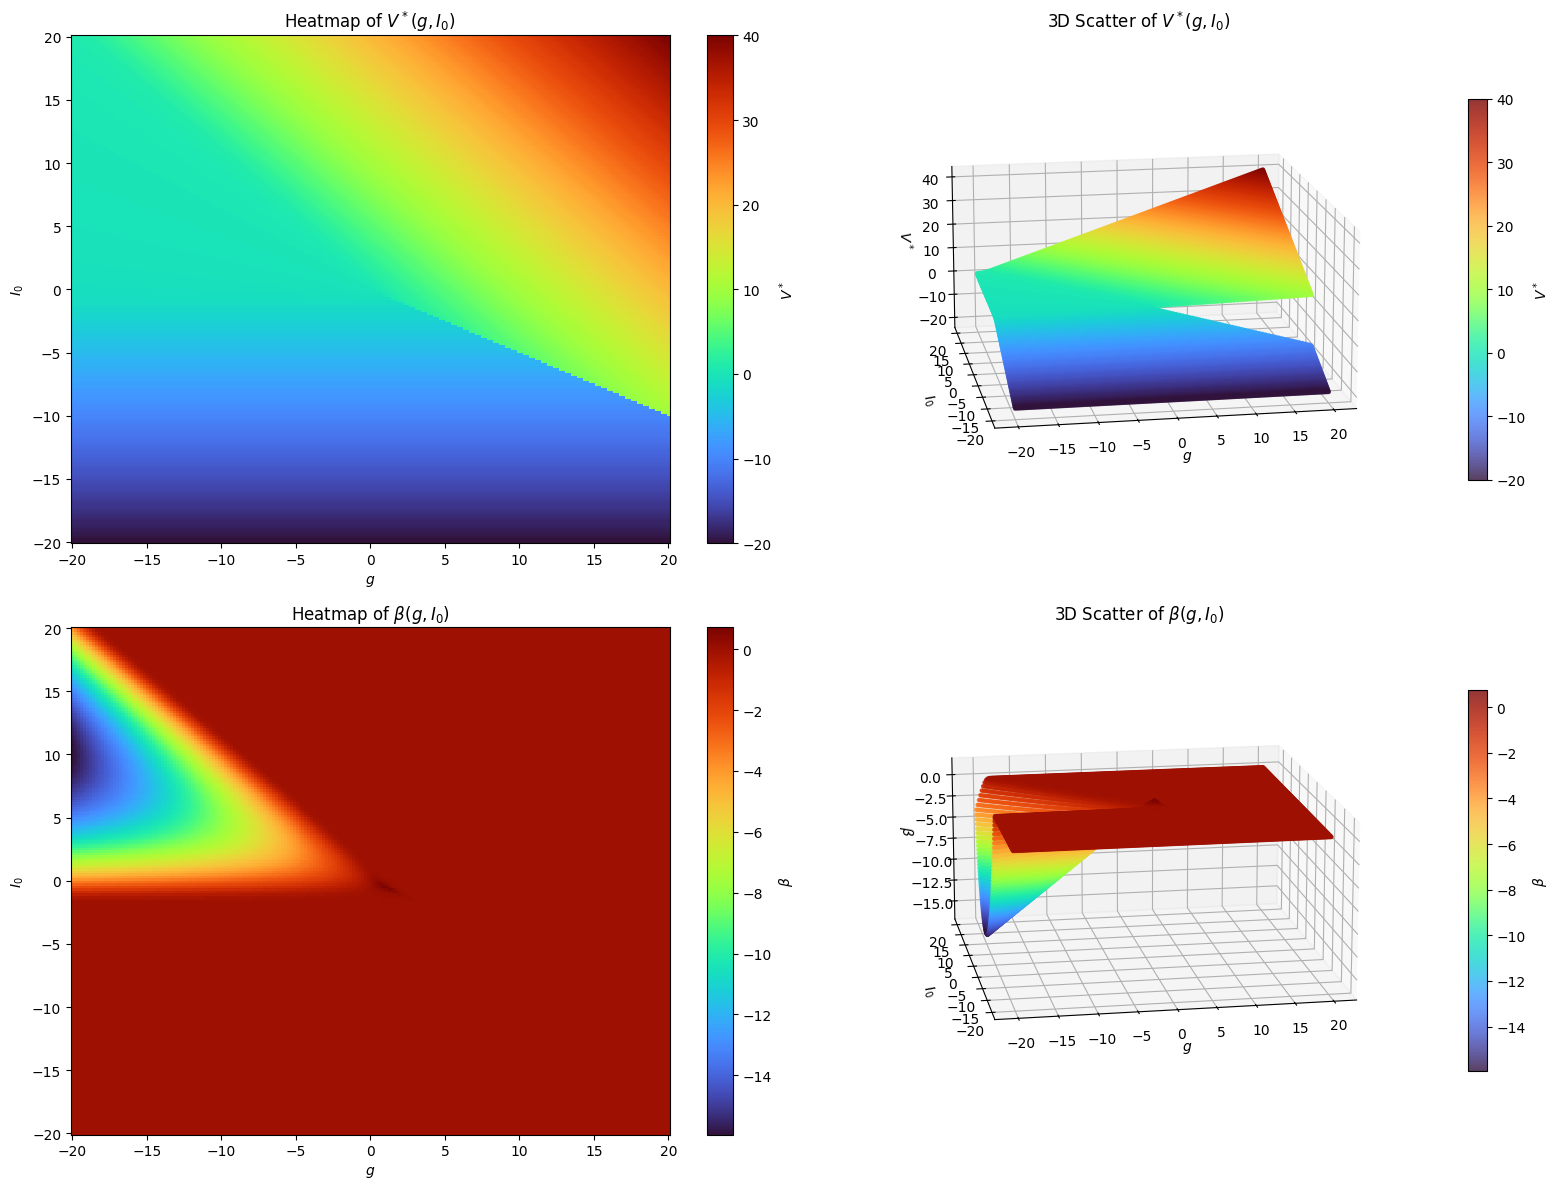

In [32]:

fig = plt.figure(figsize=(16, 12))

cmap = "turbo"

# =====================================================
# 1. V* heatmap
# =====================================================

ax1 = fig.add_subplot(2, 2, 1)

pcm1 = ax1.pcolormesh(
    g_grid,
    I0_grid,
    V_star_grid,
    shading="auto",
    cmap=cmap,
)

ax1.set_xlabel(r"$g$")
ax1.set_ylabel(r"$I_0$")
ax1.set_title(r"Heatmap of $V^*(g,I_0)$")

cbar1 = fig.colorbar(pcm1, ax=ax1)
cbar1.set_label(r"$V^*$")


# =====================================================
# 2. V* 3D scatter
# =====================================================

ax2 = fig.add_subplot(2, 2, 2, projection="3d")

scatter1 = ax2.scatter(
    g_grid.ravel(),
    I0_grid.ravel(),
    V_star_grid.ravel(),
    c=V_star_grid.ravel(),
    cmap=cmap,
    s=5,
    alpha=0.8,
)

ax2.view_init(
    elev=15,
    azim=-100,
)

ax2.set_box_aspect((1, 1, 0.5))

ax2.set_xlabel(r"$g$")
ax2.set_ylabel(r"$I_0$")
ax2.set_zlabel(r"$V^*$")
ax2.set_title(r"3D Scatter of $V^*(g,I_0)$")

cbar2 = fig.colorbar(
    scatter1,
    ax=ax2,
    shrink=0.75,
    pad=0.1,
)
cbar2.set_label(r"$V^*$")


# =====================================================
# 3. Beta heatmap
# =====================================================

ax3 = fig.add_subplot(2, 2, 3)

pcm2 = ax3.pcolormesh(
    g_grid,
    I0_grid,
    beta_grid,
    shading="auto",
    cmap=cmap,
)

ax3.set_xlabel(r"$g$")
ax3.set_ylabel(r"$I_0$")
ax3.set_title(r"Heatmap of $\beta(g,I_0)$")

cbar3 = fig.colorbar(pcm2, ax=ax3)
cbar3.set_label(r"$\beta$")


# =====================================================
# 4. Beta 3D scatter
# =====================================================

ax4 = fig.add_subplot(2, 2, 4, projection="3d")

scatter2 = ax4.scatter(
    g_grid.ravel(),
    I0_grid.ravel(),
    beta_grid.ravel(),
    c=beta_grid.ravel(),
    cmap=cmap,
    s=5,
    alpha=0.8,
)

ax4.view_init(
    elev=15,
    azim=-100,
)

ax4.set_box_aspect((1, 1, 0.5))

ax4.set_xlabel(r"$g$")
ax4.set_ylabel(r"$I_0$")
ax4.set_zlabel(r"$\beta$")
ax4.set_title(r"3D Scatter of $\beta(g,I_0)$")

cbar4 = fig.colorbar(
    scatter2,
    ax=ax4,
    shrink=0.75,
    pad=0.1,
)
cbar4.set_label(r"$\beta$")

plt.tight_layout()
plt.savefig(str(IMAGES_DIR) + "/V_star_map.jpg", dpi=300,)
plt.show()

$$
(g,I_0)
\;\longrightarrow\;
V^*(g,I_0)
\;\longrightarrow\;
\beta(g,I_0)
=
g\,S'\!\left(V^*(g,I_0)\right)
$$